In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc

plt.rcParams.update({
    "font.size": 13,
    "font.family": "serif",
    "mathtext.fontset": "cm",  # This gives the LaTeX look to math text
    "axes.edgecolor": "black", # Black bounding box
    "axes.linewidth": 0.8
})

In [3]:
def find_reflection_point(receiver, target, x_wall=None, y_wall=None):

    x1, y1 = receiver
    x2, y2 = target

    if x_wall is not None:

        y_r = (y1 * (x2 - x_wall) + y2 * (x1 - x_wall)) / (x1 + x2 - 2 * x_wall)
        return (x_wall, y_r)
    
    if y_wall is not None:

        x_r = (x1 * (y2 - y_wall) + x2 * (y1 - y_wall)) / (y1 + y2 - 2 * y_wall)
        return (x_r, y_wall)


def tdoa_hyperbola(focus1, focus2, diff_dist, num_points=100, x_bounds=None, y_bounds=None):
    x1, y1 = focus1
    x2, y2 = focus2

    a = abs(diff_dist) / 2
    c = np.sqrt((x2 - x1)**2 + (y2 - y1)**2) / 2
    
    if c <= a:
        raise ValueError("Invalid hyperbola: distance between foci must be greater than diff_dist.")
        
    b = np.sqrt(c**2 - a**2)

    center_x = (x1 + x2) / 2
    center_y = (y1 + y2) / 2
    angle = np.arctan2(y2 - y1, x2 - x1)

    t = np.linspace(-3, 3, num_points)  # Parameter for hyperbola points

    if diff_dist >= 0:  # Closer to focus 2 (Right Branch)
        x_raw = center_x + a * np.cosh(t) * np.cos(angle) - b * np.sinh(t) * np.sin(angle)
        y_raw = center_y + a * np.cosh(t) * np.sin(angle) + b * np.sinh(t) * np.cos(angle)

    else:  # Closer to focus 1 (Left Branch)
        x_raw = center_x - a * np.cosh(t) * np.cos(angle) - b * np.sinh(t) * np.sin(angle)
        y_raw = center_y - a * np.cosh(t) * np.sin(angle) + b * np.sinh(t) * np.cos(angle)

    mask = np.ones_like(x_raw, dtype=bool) 
        
    # Update the mask based on provided bounds
    if x_bounds:
        mask &= (x_raw >= x_bounds[0]) & (x_raw <= x_bounds[1])
    if y_bounds:
        mask &= (y_raw >= y_bounds[0]) & (y_raw <= y_bounds[1])

    x = x_raw[mask]
    y = y_raw[mask]

    return x, y

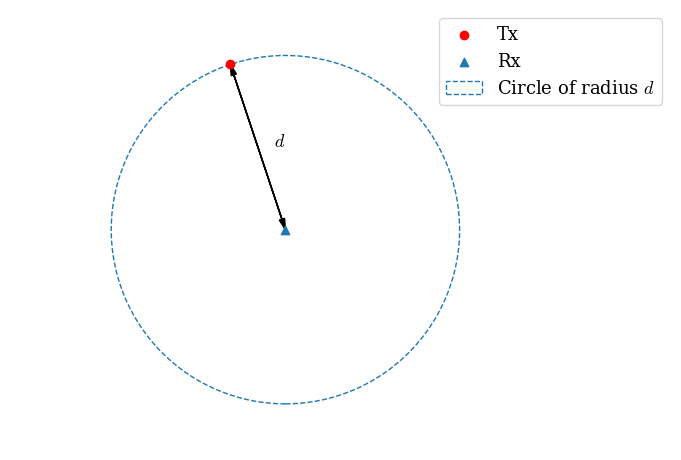

In [93]:
Rx = np.array([2.5, 2.5])

Tx = np.array([2, 4])

dist = np.linalg.norm(Rx - Tx)
circle = plt.Circle(Rx, dist, color='tab:blue', fill=False, linestyle='--', label=f'Circle of radius $d$')
arrow_vec = Tx - Rx

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(*Tx, color='red', label='Tx', zorder=5)
ax.scatter(*Rx, marker='^', color='tab:blue', label='Rx', zorder=5)
ax.add_patch(circle)
# double arrow from Rx to Tx
ax.arrow(Rx[0], Rx[1], arrow_vec[0], arrow_vec[1], head_width=0.05, head_length=0.1, fc='black', ec='black', length_includes_head=True)
ax.arrow(Tx[0], Tx[1], -arrow_vec[0], -arrow_vec[1], head_width=0.05, head_length=0.1, fc='black', ec='black', length_includes_head=True)
# Write distance label
mid_point = Rx + 0.5 * arrow_vec
ax.text(mid_point[0]+0.2, mid_point[1]+0.05, f'$d$', fontsize=13, color='black', ha='center', va='center', backgroundcolor='white')

ax.set_xlim(0, 6)
ax.set_ylim(0.5, 4.5)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal', adjustable='box')
#remove border
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.legend()

ax.grid(True, linestyle='--', linewidth=0.5, color='#D3D3D3')

plt.tight_layout()
plt.savefig("images/geometry/toa.pdf", bbox_inches='tight')
plt.show()

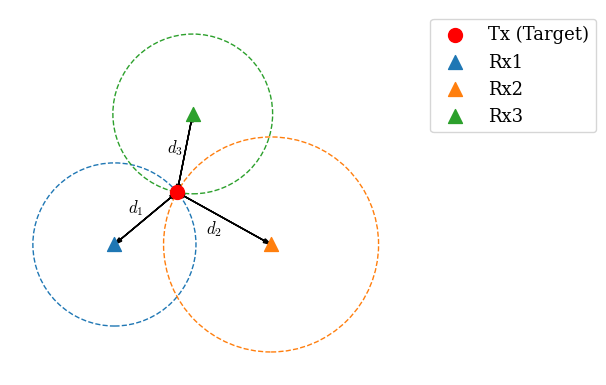

In [94]:
# Define 3 Receivers and 1 Transmitter
Rx1 = np.array([1.5, 1.5])
Rx2 = np.array([4.5, 1.5])
Rx3 = np.array([3.0, 4.0])
Tx = np.array([2.7, 2.5])

receivers = [Rx1, Rx2, Rx3]
colors = ['tab:blue', 'tab:orange', 'tab:green']
deltas = [[-0.2, 0.2], [-0.2, -0.2], [-0.2, 0.1]]

fig, ax = plt.subplots(figsize=(6, 5))

# Plot Transmitter
ax.scatter(*Tx, color='red', label='Tx (Target)', zorder=5, s=100)

# Iterate through each receiver to plot circles and arrows
for i, Rx in enumerate(receivers):
    dist = np.linalg.norm(Rx - Tx)
    
    # Draw Circle
    circle = plt.Circle(Rx, dist, fill=False, linestyle='--', color=colors[i])
    ax.add_patch(circle)
    
    # Plot Receiver
    ax.scatter(*Rx, marker='^', label=f'Rx{i+1}', zorder=5, s=100, color=colors[i])
    
    # Draw Double Arrow
    arrow_vec = Tx - Rx
    ax.arrow(Rx[0], Rx[1], arrow_vec[0], arrow_vec[1], head_width=0.08, head_length=0.15, fc='black', ec='black', length_includes_head=True)
    ax.arrow(Tx[0], Tx[1], -arrow_vec[0], -arrow_vec[1], head_width=0.08, head_length=0.15, fc='black', ec='black', length_includes_head=True)
    
    # Write distance label
    mid_point = Rx + 0.5 * arrow_vec
    ax.text(mid_point[0] + deltas[i][0], mid_point[1] + deltas[i][1], f'$d_{i+1}$', fontsize=12, color='black', ha='center', va='center', backgroundcolor='white', zorder=0)

# Configure plot limits and appearance
ax.set_xlim(-0.5, 7)
ax.set_ylim(-1, 6)
ax.set_aspect('equal', adjustable='box')
ax.set_xticks([])
ax.set_yticks([])

# Remove borders
for spine in ax.spines.values():
    spine.set_visible(False)

# Add legend outside the plot
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, linestyle='--', linewidth=0.5, color='#D3D3D3')

plt.tight_layout()
plt.savefig("images/geometry/trilateration.pdf", bbox_inches='tight')
plt.show()

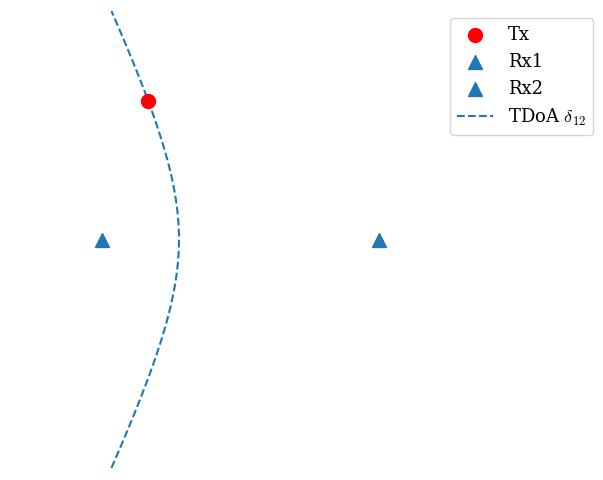

In [95]:
Rx1 = np.array([1.5, 2.5])
Rx2 = np.array([4.5, 2.5])
Tx = np.array([2, 4])

dist1 = np.linalg.norm(Rx1 - Tx)
dist2 = np.linalg.norm(Rx2 - Tx)
diff12 = dist1 - dist2

hyperbola2 = tdoa_hyperbola(Rx1, Rx2, diff12, num_points=200, x_bounds=(0, 6), y_bounds=(0, 5))


fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(*Tx, color='red', s=100, label='Tx', zorder=5)
ax.scatter(*Rx1, marker='^', s=100, color='tab:blue', label='Rx1', zorder=5)
ax.scatter(*Rx2, marker='^', s=100, color='tab:blue', label='Rx2', zorder=5)
ax.plot(hyperbola2[0], hyperbola2[1], label=r'TDoA $\delta_{12}$', linestyle='--', color='tab:blue')

ax.set_xlim(0.5, 6)
ax.set_ylim(0, 5)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal', adjustable='box')
#remove border
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.legend(bbox_to_anchor=(0.85, 1), loc='upper left')

ax.grid(True, linestyle='--', linewidth=0.5, color='#D3D3D3')

plt.tight_layout()
plt.savefig("images/geometry/tdoa.pdf", bbox_inches='tight')
plt.show()

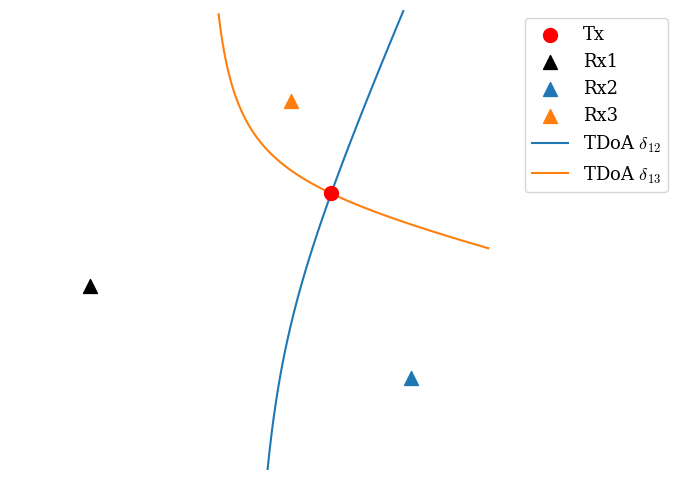

In [96]:
Rx1 = np.array([1, 2])
Rx2 = np.array([5, 1])
Rx3 = np.array([3.5, 4])
Tx = np.array([4, 3])

dist1 = np.linalg.norm(Rx1 - Tx)
dist2 = np.linalg.norm(Rx2 - Tx)
dist3 = np.linalg.norm(Rx3 - Tx)

diff12 = dist1 - dist2
diff13 = dist1 - dist3

hyperbola2 = tdoa_hyperbola(Rx1, Rx2, diff12, num_points=200, x_bounds=(0, 6), y_bounds=(0, 5))
hyperbola3 = tdoa_hyperbola(Rx1, Rx3, diff13, num_points=200, x_bounds=(0, 6), y_bounds=(0, 5))


fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(*Tx, color='red', s=100, label='Tx', zorder=5)
ax.scatter(*Rx1, marker='^', color='black', s=100, label='Rx1', zorder=5)
ax.scatter(*Rx2, marker='^', color='tab:blue', s=100, label='Rx2', zorder=5)
ax.scatter(*Rx3, marker='^', color='tab:orange', s=100, label='Rx3', zorder=5)
ax.plot(hyperbola2[0], hyperbola2[1], label=r'TDoA $\delta_{12}$', color='tab:blue')
ax.plot(hyperbola3[0], hyperbola3[1], label=r'TDoA $\delta_{13}$', color='tab:orange')

ax.set_xlim(0, 6)
ax.set_ylim(0, 5)
ax.set_xticks([])
ax.set_yticks([])
#remove border
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

ax.grid(True, linestyle='--', linewidth=0.5, color='#D3D3D3')

plt.tight_layout()
plt.savefig("images/geometry/multilateration.pdf", bbox_inches='tight')
plt.show()

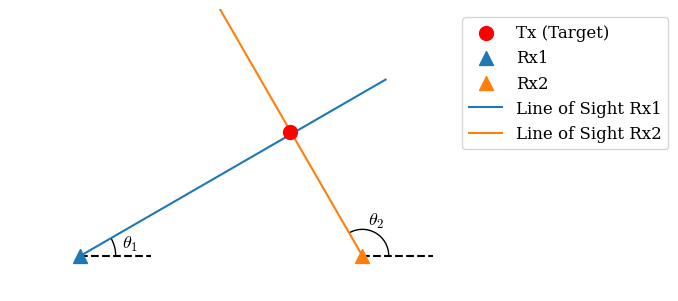

In [109]:
Rx1 = np.array([1, 1])
Rx2 = np.array([5, 1])

theta1 = np.radians(30)
theta2 = np.radians(120)

intersection = np.array([3.97, 2.75])  # Intersection point of the two lines of sight

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(*intersection, color='red', s=100, label='Tx (Target)', zorder=5)
ax.scatter(*Rx1, marker='^', color='tab:blue', s=100, label='Rx1', zorder=5)
ax.scatter(*Rx2, marker='^', color='tab:orange', s=100, label='Rx2', zorder=5)
ax.plot([Rx1[0], Rx1[0] + 5 * np.cos(theta1)], [Rx1[1], Rx1[1] + 5 * np.sin(theta1)], label=r'Line of Sight Rx1', color='tab:blue')
ax.plot([Rx2[0], Rx2[0] + 5 * np.cos(theta2)], [Rx2[1], Rx2[1] + 5 * np.sin(theta2)], label=r'Line of Sight Rx2', color='tab:orange')

arc1 = Arc(Rx1, 1, 1, angle=0, theta1=0, theta2=np.degrees(theta1), color='black', linestyle='-')
ax.add_patch(arc1)
ax.plot([Rx1[0], Rx1[0]+1], [Rx1[1], Rx1[1]], 'k--') # Base line
ax.text(Rx1[0]+0.7, Rx1[1]+0.175, r'$\theta_1$', fontsize=13, color='black', ha='center', va='center', backgroundcolor='white', zorder=0)


arc2 = Arc(Rx2, 0.75, 0.75, angle=0, theta1=0, theta2=np.degrees(theta2), color='black', linestyle='-', )
ax.add_patch(arc2)
ax.plot([Rx2[0], Rx2[0]+1], [Rx2[1], Rx2[1]], 'k--') # Base line
ax.text(Rx2[0]+0.2, Rx2[1]+0.5, r'$\theta_2$', fontsize=13, color='black', ha='center', va='center', backgroundcolor='white', zorder=0)

ax.set_xlim(0, 6)
ax.set_ylim(0.5, 4.5)
ax.set_xticks([])
ax.set_yticks([])
#remove border
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')   

ax.grid(True, linestyle='--', linewidth=0.5, color='#D3D3D3')
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig("images/geometry/triangulation.pdf", bbox_inches='tight')
plt.show()

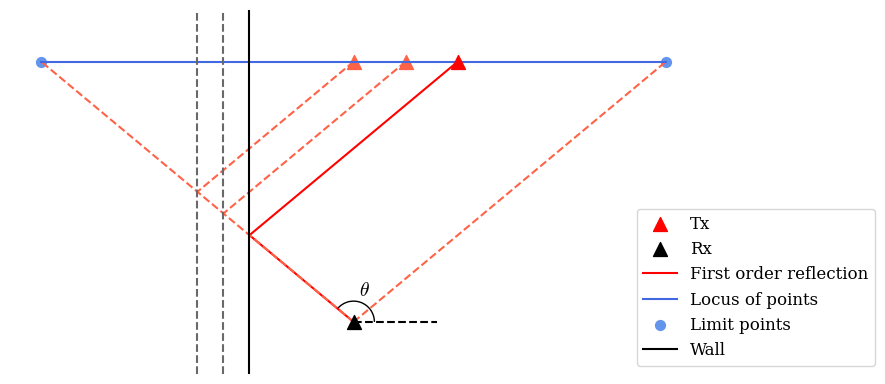

In [4]:
plt.rcParams.update({
    "font.size": 12,
    "font.family": "serif",
    "mathtext.fontset": "cm",  # This gives the LaTeX look to math text
    "axes.edgecolor": "black", # Black bounding box
    "axes.linewidth": 0.8
})


height = 12.5
Rx = np.array([2.5, 0])
Txs = [np.array([7.5, height]), np.array([5.0, height]), np.array([2.5, height])]

reflection_point1 = find_reflection_point(Rx, Txs[0], x_wall=-2.5)
reflection_point2 = find_reflection_point(Rx, Txs[1], x_wall=-3.75)
reflection_point3 = find_reflection_point(Rx, Txs[2], x_wall=-5)


fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(*Txs[0], marker='^', color='red', s=100, label='Tx', zorder=5)
ax.scatter(*Rx, marker='^', color='black', s=100, label='Rx', zorder=5)
# Ghost tx
ax.scatter(Txs[1][0], Txs[1][1], marker='^', color='tomato', s=100)
ax.scatter(Txs[2][0], Txs[2][1], marker='^', color='tomato', s=100)

ax.plot([Txs[0][0], reflection_point1[0]], [Txs[0][1], reflection_point1[1]], color='red', linestyle='-', label='First order reflection')
ax.plot([reflection_point1[0], Rx[0]], [reflection_point1[1], Rx[1]], color='red', linestyle='-')

ax.plot([Txs[1][0], reflection_point2[0]], [Txs[1][1], reflection_point2[1]], color='tomato', linestyle='--')

ax.plot([Txs[2][0], reflection_point3[0]], [Txs[2][1], reflection_point3[1]], color='tomato', linestyle='--')
# ax.plot([reflection_point3[0], Rx[0]], [reflection_point3[1], Rx[1]], color='tomato', linestyle='--')

ax.plot([Rx[0], -12.5], [Rx[1], height], color='tomato', linestyle='--')
ax.plot([Rx[0], 17.5], [Rx[1], height], color='tomato', linestyle='--')


ax.plot([-12.5, 17.5], [height, height], color='royalblue', linestyle='-', label='Locus of points')
ax.scatter([-12.5, 17.5], [height, height], marker='o', color='cornflowerblue', s=50, label='Limit points')
ax.axvline(x=-2.5, color='black', linestyle='-', label='Wall')
ax.axvline(x=-3.75, color='dimgray', linestyle='--')
ax.axvline(x=-5, color='dimgray', linestyle='--')

arc = Arc(Rx, 2, 2, angle=0, theta1=0, theta2=140, color='black', linestyle='-')
ax.add_patch(arc)
ax.plot([Rx[0], Rx[0]+4], [Rx[1], Rx[1]], 'k--') # Base line
ax.text(Rx[0]+0.5, Rx[1]+1.5, r'$\theta$', fontsize=14, color='black', ha='center', va='center', backgroundcolor='white', zorder=0)

# ax.set_xlim(-10, 10)
ax.set_ylim(-2.5, 15)
ax.set_xticks([])
ax.set_yticks([])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# legend outside the plot
ax.legend(bbox_to_anchor=(0.9, 0), loc='lower left')

ax.grid(True, linestyle='--', linewidth=0.5, color='#D3D3D3')
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig("images/geometry/fo-reflection.pdf", bbox_inches='tight')
plt.show()

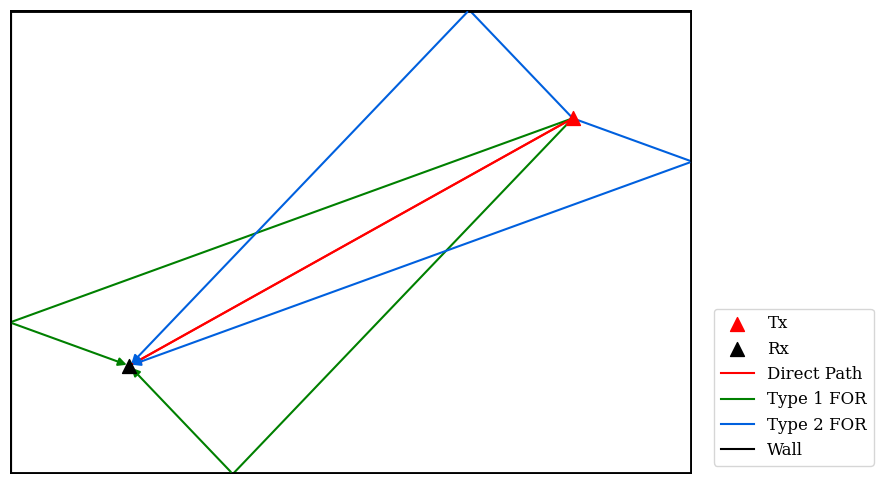

In [5]:
import numpy as np
import matplotlib.pyplot as plt

Rx = np.array([-6.5, -4])
Tx = np.array([6.5, 4])

# (Assuming your find_reflection_point function is defined above)
reflection_point1 = find_reflection_point(Rx, Tx, x_wall=-10)
reflection_point2 = find_reflection_point(Rx, Tx, x_wall=10)
reflection_point3 = find_reflection_point(Rx, Tx, y_wall=-7.5)
reflection_point4 = find_reflection_point(Rx, Tx, y_wall=7.5)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(*Tx, marker='^', color='red', s=100, label='Tx', zorder=5)
ax.scatter(*Rx, marker='^', color='black', s=100, label='Rx', zorder=5)

# --- Direct Path ---
ax.plot([Tx[0], Rx[0]], [Tx[1], Rx[1]], color='red', linestyle='-', label='Direct Path')
# Add arrow on top of the direct path pointing to Rx
ax.annotate("", xy=Rx, xytext=Tx, 
            arrowprops=dict(arrowstyle="-|>", color='red', lw=1.5, mutation_scale=12))

# --- FO Type 1 (Left Wall) ---
ax.plot([Tx[0], reflection_point1[0]], [Tx[1], reflection_point1[1]], color='green', linestyle='-', label='Type 1 FOR')
# Replaced second line with an annotation pointing to Rx
ax.annotate("", xy=Rx, xytext=reflection_point1, 
            arrowprops=dict(arrowstyle="-|>", color='green', lw=1.5, mutation_scale=12))

# --- FO Type 2 (Right Wall) ---
ax.plot([Tx[0], reflection_point2[0]], [Tx[1], reflection_point2[1]], color='#0060DE', linestyle='-', label='Type 2 FOR')
# Replaced second line with an annotation pointing to Rx
ax.annotate("", xy=Rx, xytext=reflection_point2, 
            arrowprops=dict(arrowstyle="-|>", color='#0060DE', lw=1.5, mutation_scale=12))

# --- FO Type 3 (Bottom Wall) ---
ax.plot([Tx[0], reflection_point3[0]], [Tx[1], reflection_point3[1]], color='green', linestyle='-')
# Replaced second line with an annotation pointing to Rx
ax.annotate("", xy=Rx, xytext=reflection_point3, 
            arrowprops=dict(arrowstyle="-|>", color='green', lw=1.5, mutation_scale=12))

# --- FO Type 4 (Top Wall) ---
ax.plot([Tx[0], reflection_point4[0]], [Tx[1], reflection_point4[1]], color='#0060DE', linestyle='-')
# Replaced second line with an annotation pointing to Rx
ax.annotate("", xy=Rx, xytext=reflection_point4, 
            arrowprops=dict(arrowstyle="-|>", color='#0060DE', lw=1.5, mutation_scale=12))

ax.axhline(y=-7.5, color='black', linestyle='-', linewidth=1.5, label='Wall')
ax.axhline(y=-7.5, color='black', linestyle='-', linewidth=3.5)
ax.axhline(y=7.5, color='black', linestyle='-', linewidth=3.5)
ax.axvline(x=-10, color='black', linestyle='-', linewidth=3)
ax.axvline(x=10, color='black', linestyle='-', linewidth=3.5)

# --- Formatting ---
ax.set_xlim(-10, 10)
ax.set_ylim(-7.5, 7.5)
ax.set_xticks([])
ax.set_yticks([])

ax.legend(loc='lower left', bbox_to_anchor=(1.02, 0.0))

ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("images/geometry/fo-types.pdf", bbox_inches='tight')
plt.show()

Path 1 Length: 11.31
Path 2 Length: 11.31


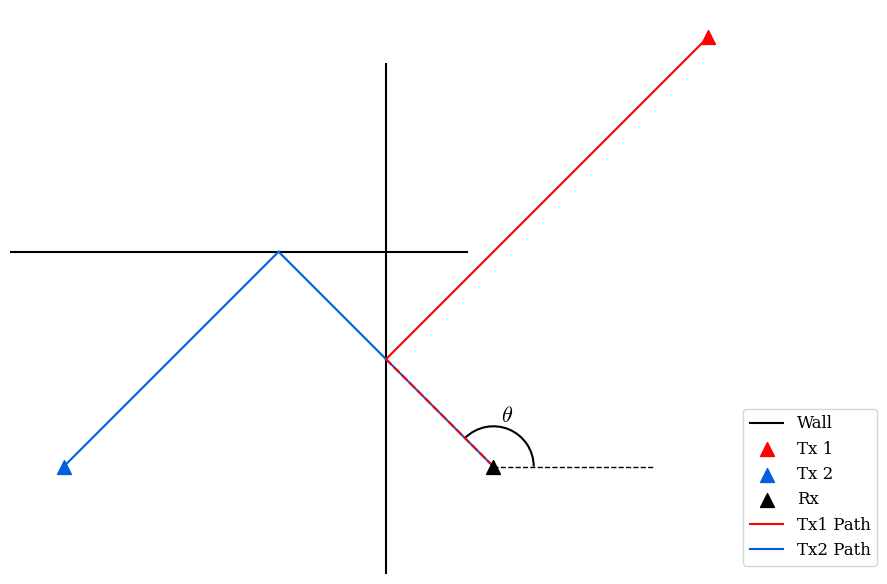

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc

# Update rcParams for LaTeX styling
plt.rcParams.update({
    "font.size": 12,
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.edgecolor": "black",
    "axes.linewidth": 0.8
})

def find_reflection_point(rx, tx, wall_coord, wall_type='vertical'):
    """
    Computes the reflection point on a wall given Rx and Tx coordinates
    using the method of images.
    """
    if wall_type == 'vertical':
        x_wall = wall_coord
        rx_image = np.array([x_wall - (rx[0] - x_wall), rx[1]])
        m = (tx[1] - rx_image[1]) / (tx[0] - rx_image[0])
        b = tx[1] - m * tx[0]
        y_int = m * x_wall + b
        return np.array([x_wall, y_int])
        
    elif wall_type == 'horizontal':
        y_wall = wall_coord
        rx_image = np.array([rx[0], y_wall - (rx[1] - y_wall)])
        m = (tx[1] - rx_image[1]) / (tx[0] - rx_image[0])
        b = tx[1] - m * tx[0]
        x_int = (y_wall - b) / m
        return np.array([x_int, y_wall])

# 1. Define mathematically derived coordinates
Rx = np.array([0, 0])
Tx1 = np.array([4, 8])   # Path 1 source
Tx2 = np.array([-8, 0])  # Path 2 source

wall_x = -2 # Vertical wall
wall_y = 4  # Horizontal wall

# 2. Compute reflection points
R1 = find_reflection_point(Rx, Tx1, wall_coord=wall_x, wall_type='vertical')
R2 = find_reflection_point(Rx, Tx2, wall_coord=wall_y, wall_type='horizontal')

# --- Proof of Concept (Prints to console) ---
path1_len = np.linalg.norm(Tx1 - R1) + np.linalg.norm(R1 - Rx)
path2_len = np.linalg.norm(Tx2 - R2) + np.linalg.norm(R2 - Rx)
print(f"Path 1 Length: {path1_len:.2f}")
print(f"Path 2 Length: {path2_len:.2f}")

# 3. Plotting Setup
fig, ax = plt.subplots(figsize=(9, 6))

# Plot walls (limited coordinates so they don't visually block the rays)
ax.plot([wall_x, wall_x], [-2, 7.5], color='black', linewidth=1.5, label='Wall')
ax.plot([-10, -0.5], [wall_y, wall_y], color='black', linewidth=1.5)

# Plot Transmitters and Receiver
ax.scatter(*Tx1, marker='^', color='red', s=100, label='Tx 1', zorder=5)
ax.scatter(*Tx2, marker='^', color='#0060DE', s=100, label='Tx 2', zorder=5)
ax.scatter(*Rx, marker='^', color='black', s=100, label='Rx', zorder=5)

# Plot Path 1 (Solid Red)
ax.plot([Tx1[0], R1[0]], [Tx1[1], R1[1]], color='red', linestyle='-', label='Tx1 Path')
ax.plot([R1[0], Rx[0]], [R1[1], Rx[1]], color='red', linestyle='--', zorder=4)

# Plot Path 2 (Dashed Tomato - plotted second so dashes show over solid red)
ax.plot([Tx2[0], R2[0]], [Tx2[1], R2[1]], color='#0060DE', linestyle='-', label='Tx2 Path')
ax.plot([R2[0], Rx[0]], [R2[1], Rx[1]], color='#0060DE', linestyle='-')

# Mark Reflection points
# ax.scatter(*R1, color='black', s=30, zorder=6)
# ax.scatter(*R2, color='black', s=30, zorder=6)

# Angle of arrival Arc (Both arrive identically at 135 degrees)
ax.plot([Rx[0], Rx[0]+3], [Rx[1], Rx[1]], 'k--', linewidth=1) # X-axis reference
arc = Arc(Rx, 1.5, 1.5, angle=0, theta1=0, theta2=135, color='black', linestyle='-', linewidth=1.5)
ax.add_patch(arc)
ax.text(Rx[0]+0.25, Rx[1]+0.95, r'$\theta$', fontsize=16, color='black', ha='center', va='center', backgroundcolor='white', zorder=0)

# Set axes limits to fit everything beautifully
ax.set_xlim(-9, 6)
ax.set_ylim(-2, 8.5)

# Clean up axes based on your original styling
ax.set_xticks([])
ax.set_yticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# Legend outside the plot
ax.legend(bbox_to_anchor=(0.9, 0), loc='lower left')

ax.grid(True, linestyle='--', linewidth=0.5, color='#D3D3D3')
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig("images/geometry/reflection-random.pdf", bbox_inches='tight')
plt.show()

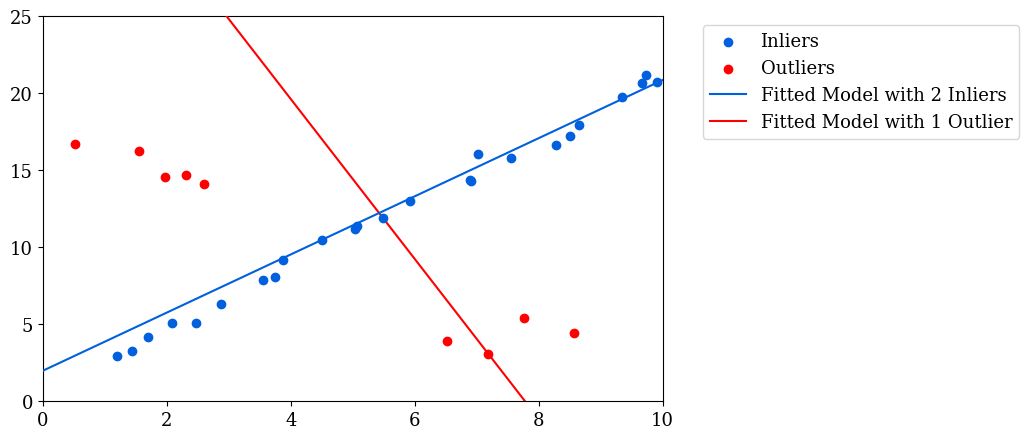

In [ ]:
# RANSAC example

x_inliers = np.random.rand(25) * 10
y_inliers = 2 * x_inliers + 1 + np.random.randn(25) * 0.5
x_outliers = np.concatenate([2.5 + np.random.randn(6) * 1.5, 7.5 + np.random.randn(4) * 1.2])
y_outliers = np.concatenate([15 + np.random.randn(6) * 1.5, 5 + np.random.randn(4) * 1.2])


x = np.linspace(0, 10, 100)

random_inliers = np.random.choice(len(x_inliers), size=2, replace=False)
x_random_inliers = x_inliers[random_inliers]
y_random_inliers = y_inliers[random_inliers]
m_inlier = (y_random_inliers[1] - y_random_inliers[0]) / (x_random_inliers[1] - x_random_inliers[0])
p_inlier = y_random_inliers[0] - m_inlier * x_random_inliers[0]
y_line = m_inlier * x + p_inlier

random_outlier = np.random.choice(len(x_outliers), size=1, replace=False)
random_inlier = np.random.choice(len(x_inliers), size=1, replace=False)
m_mix = (y_outliers[random_outlier][0] - y_inliers[random_inlier][0]) / (x_outliers[random_outlier][0] - x_inliers[random_inlier][0])
p_mix = y_outliers[random_outlier][0] - m_mix * x_outliers[random_outlier][0]
y_mix = m_mix * x + p_mix

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x_inliers, y_inliers, color='#0060DE', label='Inliers', zorder=5)
ax.scatter(x_outliers, y_outliers, color='red', label='Outliers', zorder=5)
ax.plot(x, y_line, color='#0060DE', label='Fitted Model with 2 Inliers', zorder=5)
ax.plot(x, y_mix, color='red', label='Fitted Model with 1 Outlier', zorder=4, linestyle='-')

ax.set_xlim(0, 10)
ax.set_ylim(0, 25)

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.savefig("images/geometry/ransac.pdf", bbox_inches='tight')
plt.show()
